## LinkedIn Job Salary Classification
### Notebook 1: Data Preparation

**Student:** Goudarz Javadizadeh  
**Student Number:** 25220901017  
**Dataset:** LinkedIn Job Postings 2023–2024 (Kaggle)

### Section 1: Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Display settings
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully.")

All libraries imported successfully.


### Section 2: Data Loading and Initial Exploration

I load the raw dataset and inspect its shape, column types, and basic statistics before any cleaning.
Then I check pay period distribution.

In [2]:
df_raw = pd.read_csv('postings.csv')
print(f"Dataset shape: {df_raw.shape}")

# Statistical overview of key numeric columns
df_raw[['normalized_salary', 'med_salary', 'min_salary', 'max_salary', 'views', 'applies']].describe().round(2)

Dataset shape: (123849, 31)


,normalized_salary,med_salary,min_salary,max_salary,views,applies
count,3.607300e+04,6280.00,29793.00,2.979300e+04,122160.00,23320.00
mean,2.053270e+05,22015.62,64910.85,9.193942e+04,14.62,10.59
std,5.097627e+06,52255.87,495973.79,7.011101e+05,85.90,29.05
min,0.000000e+00,0.00,1.00,1.000000e+00,1.00,1.00
25%,5.200000e+04,18.94,37.00,4.828000e+01,3.00,1.00
50%,8.150000e+04,25.50,60000.00,8.000000e+04,4.00,3.00
75%,1.250000e+05,2510.50,100000.00,1.400000e+05,8.00,8.00
max,5.356000e+08,750000.00,85000000.00,1.200000e+08,9975.00,967.00


In [3]:
# Pay period distribution — critical because mixing hourly/annual corrupts salary targets
print("Pay period distribution:")
print(df_raw['pay_period'].value_counts())
print(f"\n'normalized_salary' non-null count: {df_raw['normalized_salary'].notna().sum()}")

Pay period distribution:
pay_period
YEARLY      20628
HOURLY      14741
MONTHLY       518
WEEKLY        177
BIWEEKLY        9
Name: count, dtype: int64

'normalized_salary' non-null count: 36073


### Section 3: Data Pre-processing and Cleaning

I do it in four steps:
- Step 1: Drop rows without a valid salary target
- Step 2: Remove extreme salary outliers (below 5th and above 95th percentile)
- Step 3: Handle missing values per column — with justification for each choice
- Step 4: Remove duplicates

In [4]:
df = df_raw.copy()

# Step 1: Drop rows without a valid salary target
df = df.dropna(subset=['normalized_salary'])
print(f"Rows after dropping null normalized_salary: {len(df)}")

# Step 2: Remove extreme salary outliers (below 5th and above 95th percentile)
lower = df['normalized_salary'].quantile(0.05)
upper = df['normalized_salary'].quantile(0.95)
df = df[(df['normalized_salary'] >= lower) & (df['normalized_salary'] <= upper)]
print(f"Rows after outlier removal (5th-95th percentile): {len(df)}")
print(f"Salary range after filtering: ${lower:,.0f} — ${upper:,.0f}")

# Step 3: Handle missing values per column — with justification for each choice
df['formatted_experience_level'] = df['formatted_experience_level'].fillna('Unknown')
df['remote_allowed'] = df['remote_allowed'].fillna(0)
df['views'] = df['views'].fillna(df['views'].median())
df['applies'] = df['applies'].fillna(df['applies'].median())

# Step 4: Remove duplicates
before = len(df)
df = df.drop_duplicates(subset='job_id')
print(f"Duplicate rows removed: {before - len(df)}")
print(f"Final clean dataset size: {len(df)} rows")

Rows after dropping null normalized_salary: 36073
Rows after outlier removal (5th-95th percentile): 32671
Salary range after filtering: $33,280 — $200,000
Duplicate rows removed: 0
Final clean dataset size: 32671 rows


### Section 4: Feature Engineering

#### 4.1 Target Variable Construction

The binary target (high_salary) is 1 if the job's (normalized_salary) is above the median of the cleaned dataset, and 0 otherwise. 

note: For low-frequency locations (fewer than 5 postings), target encoding is unreliable, so these are grouped as (Other) before encoding.

In [5]:
# 4.1 Create binary target
median_salary = df['normalized_salary'].median()
df['high_salary'] = (df['normalized_salary'] > median_salary).astype(int)

print(f"Median annual salary (threshold): ${median_salary:,.0f}")
print(f"\nClass distribution:")
print(df['high_salary'].value_counts())
print(f"\nClass balance: {df['high_salary'].mean():.2%} above median")

Median annual salary (threshold): $81,120

Class distribution:
high_salary
0    16360
1    16311
Name: count, dtype: int64

Class balance: 49.93% above median


In [7]:
# 4.2 Feature encoding

# Label Encoding for ordinal/low-cardinality categoricals
from sklearn.preprocessing import LabelEncoder

le_work = LabelEncoder()
le_exp = LabelEncoder()

df['work_type_enc'] = le_work.fit_transform(df['formatted_work_type'].astype(str))
df['exp_level_enc'] = le_exp.fit_transform(df['formatted_experience_level'].astype(str))

# Target Encoding for location (high-cardinality nominal)
# Group rare locations first
location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts < 5].index
df['location_clean'] = df['location'].apply(lambda x: 'Other' if x in rare_locations else x)

# Compute target encoding on training data only
location_target_mean = df.groupby('location_clean')['high_salary'].mean()
df['location_enc'] = df['location_clean'].map(location_target_mean)

print(f"Unique experience levels: {df['formatted_experience_level'].unique()}")
print(f"Unique work types: {df['formatted_work_type'].unique()}")

Unique experience levels: <StringArray>
[         'Unknown', 'Mid-Senior level',        'Associate',
      'Entry level',         'Director',       'Internship',
        'Executive']
Length: 7, dtype: str
Unique work types: <StringArray>
[ 'Full-time', 'Internship',   'Contract',  'Part-time',  'Temporary',
      'Other',  'Volunteer']
Length: 7, dtype: str


In [8]:
# Define final feature set
features = [
    'work_type_enc',
    'location_enc',
    'exp_level_enc',
    'views',
    'applies',
    'remote_allowed',
    'sponsored'
]

X = df[features].copy()
y = df['high_salary'].copy()

# Fill any remaining NaN in location_enc with global mean
X['location_enc'] = X['location_enc'].fillna(y.mean())

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
X.head()

Feature matrix shape: (32671, 7)
Target shape: (32671,)


,work_type_enc,location_enc,exp_level_enc,views,applies,remote_allowed,sponsored
0,1,0.818182,6,20.0,2.0,0.0,0
1,1,0.368421,6,1.0,3.0,0.0,0
2,1,0.459770,6,8.0,3.0,0.0,0
3,1,0.334737,6,16.0,3.0,0.0,0
4,1,0.334737,6,3.0,3.0,0.0,0


### Section 5: Exploratory Data Analysis and Visualization

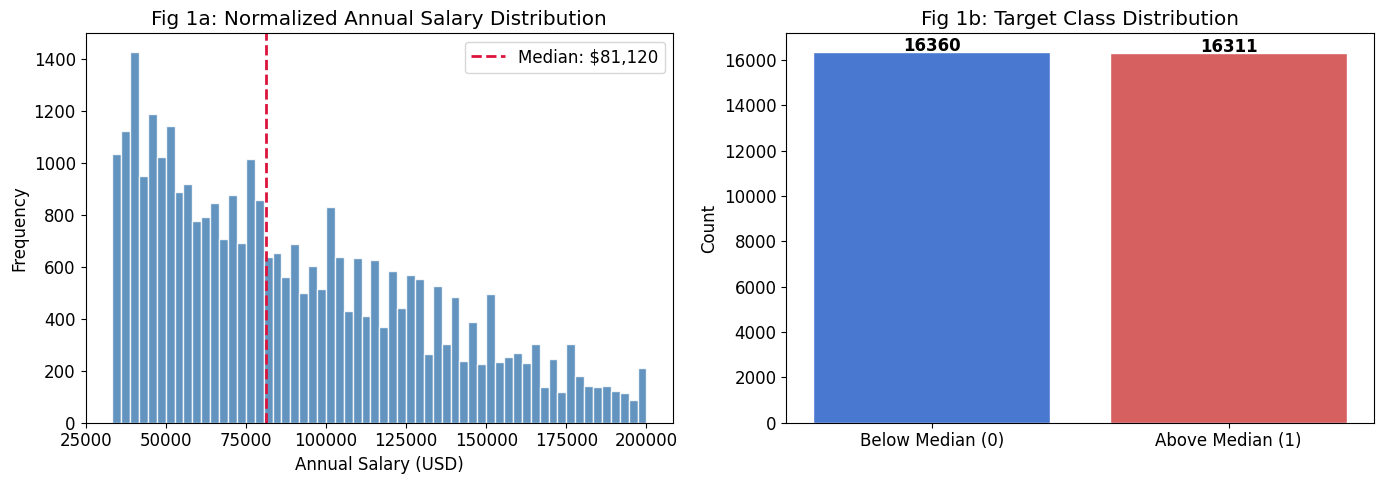

In [9]:
# Figure 1: Normalized salary distribution with median threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['normalized_salary'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(median_salary, color='crimson', linestyle='--', linewidth=2, label=f'Median: ${median_salary:,.0f}')
axes[0].set_title('Fig 1a: Normalized Annual Salary Distribution')
axes[0].set_xlabel('Annual Salary (USD)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Class balance
class_counts = df['high_salary'].value_counts()
axes[1].bar(['Below Median (0)', 'Above Median (1)'], class_counts.values,
            color=['#4878cf', '#d65f5f'], edgecolor='white')
axes[1].set_title('Fig 1b: Target Class Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

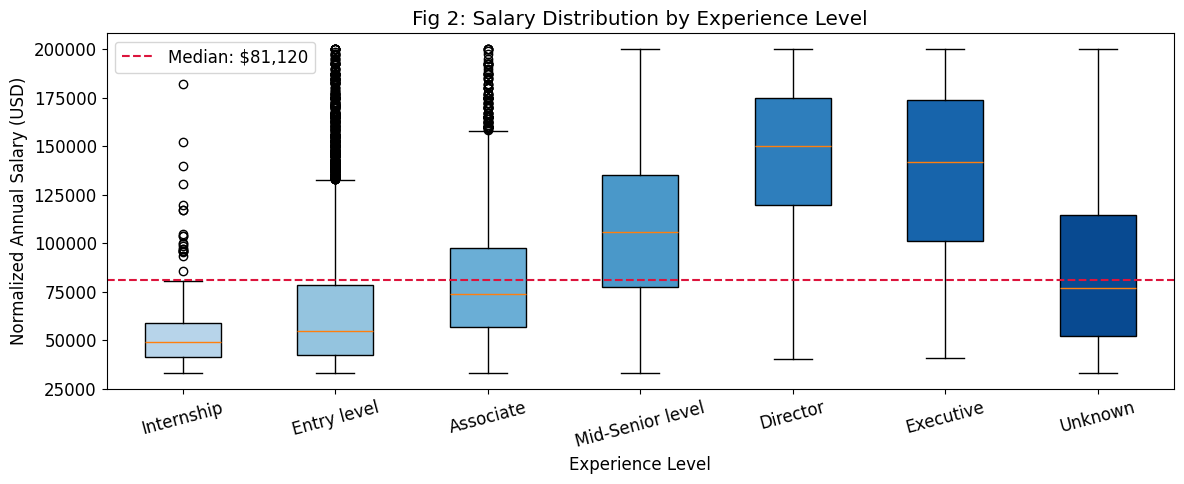

In [11]:
# Figure 2: Salary by experience level
exp_order = ['Internship', 'Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive', 'Unknown']
exp_order = [e for e in exp_order if e in df['formatted_experience_level'].unique()]

fig, ax = plt.subplots(figsize=(12, 5))
exp_data = [df[df['formatted_experience_level'] == e]['normalized_salary'].values for e in exp_order]
bp = ax.boxplot(exp_data, labels=exp_order, patch_artist=True)
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(exp_order)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.axhline(median_salary, color='crimson', linestyle='--', linewidth=1.5, label=f'Median: ${median_salary:,.0f}')
ax.set_title('Fig 2: Salary Distribution by Experience Level')
ax.set_xlabel('Experience Level')
ax.set_ylabel('Normalized Annual Salary (USD)')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

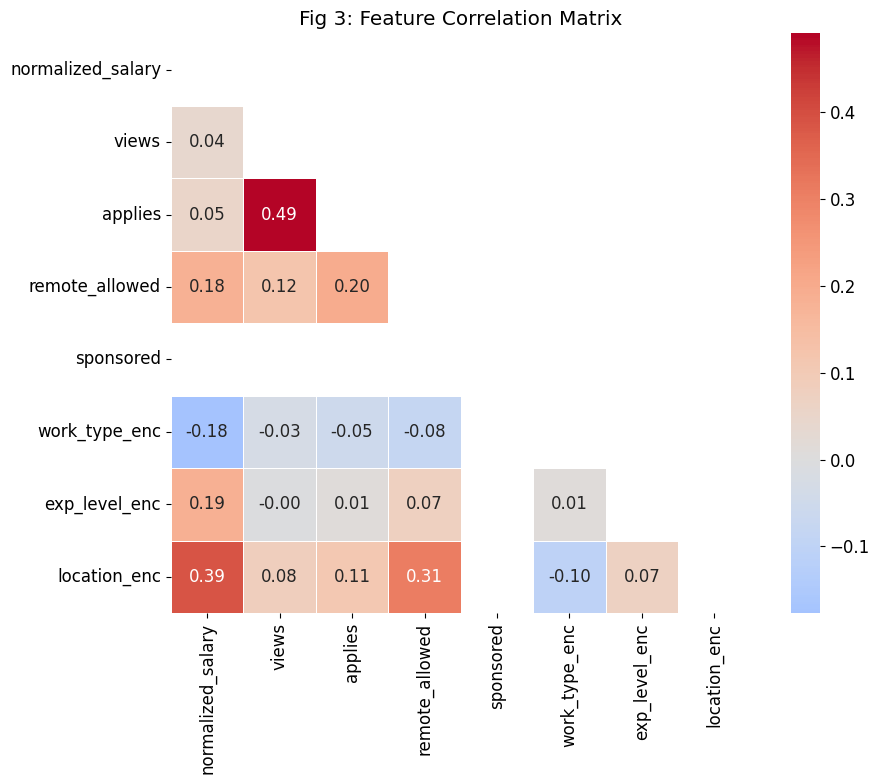

In [12]:
# Figure 3: Correlation heatmap of numeric features
corr_cols = ['normalized_salary', 'views', 'applies', 'remote_allowed', 'sponsored',
             'work_type_enc', 'exp_level_enc', 'location_enc']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Fig 3: Feature Correlation Matrix')
plt.tight_layout()
plt.show()

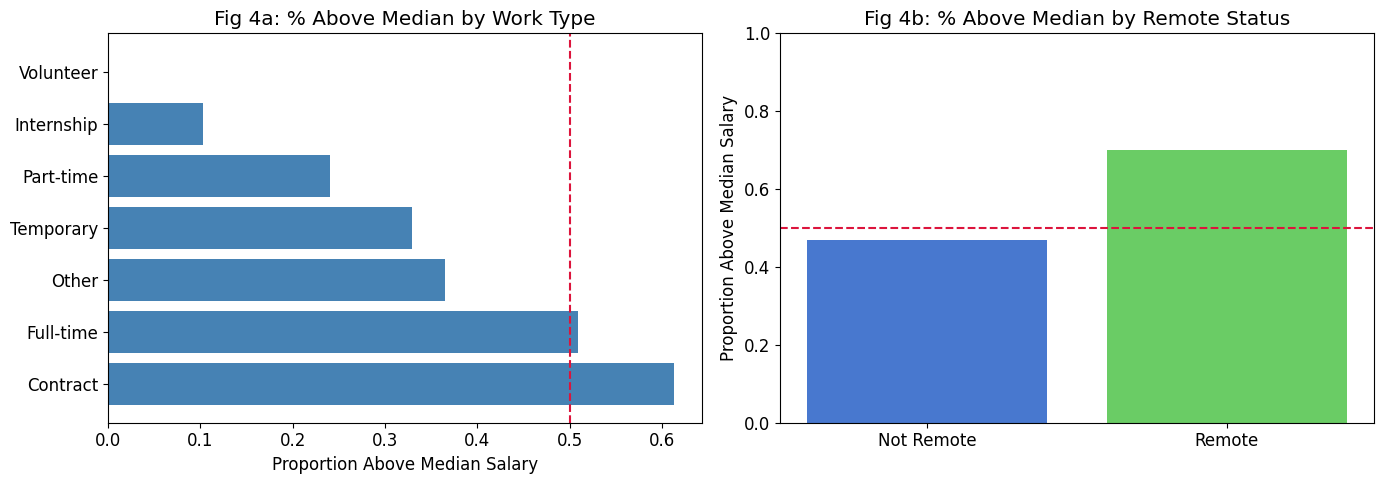

In [13]:
# Figure 4: High-salary rate by work type and remote status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Work type
work_high = df.groupby('formatted_work_type')['high_salary'].mean().sort_values(ascending=False)
axes[0].barh(work_high.index, work_high.values, color='steelblue')
axes[0].axvline(0.5, color='crimson', linestyle='--', linewidth=1.5)
axes[0].set_title('Fig 4a: % Above Median by Work Type')
axes[0].set_xlabel('Proportion Above Median Salary')

# Remote vs non-remote
remote_labels = {0: 'Not Remote', 1: 'Remote'}
remote_high = df.groupby('remote_allowed')['high_salary'].mean()
axes[1].bar([remote_labels[k] for k in remote_high.index], remote_high.values,
            color=['#4878cf', '#6acc65'])
axes[1].axhline(0.5, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_title('Fig 4b: % Above Median by Remote Status')
axes[1].set_ylabel('Proportion Above Median Salary')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [14]:
# Export cleaned and encoded dataset for use in model_dev notebook
df_export = df.copy()
df_export['work_type_enc'] = X['work_type_enc']
df_export['location_enc']  = X['location_enc']
df_export['exp_level_enc'] = X['exp_level_enc']
df_export.to_csv('linkedin_clean.csv', index=False)
print(f'Saved linkedin_clean.csv — {len(df_export)} rows')

Saved linkedin_clean.csv — 32671 rows
